# **Practical Q2: Clustering using K-means**

In this problem, the **Country-data.csv** dataset containing economic and health indicators of countries is analyzed using the **K-Means clustering algorithm**. The goal is to determine the **optimal number of clusters** using the **Elbow method**, perform clustering, compare the resulting clusters using **statistical analysis**, and visualize the clusters in both **two-dimensional** and **three-dimensional** spaces while justifying the selected features.

### Import Libraries

In [10]:
# Improting needed libraries

import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [11]:
# Load data
cust_df = pd.read_csv("Country-data.csv")
cust_df.head()

,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [12]:
# Drop 'country'
df = cust_df.drop('country', axis=1).copy()
df.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [13]:
# Prepare numeric array and scale it
X = df.values  # all numeric columns
X = np.nan_to_num(X)  # replace NaN with numeric

# Standardize features before KMeans
scaler = StandardScaler()
Clus_dataSet = scaler.fit_transform(X)
Clus_dataSet

array([[ 1.29153238, -1.13827979,  0.27908825, ..., -1.61909203,
         1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618, ...,  0.64786643,
        -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, ...,  0.67042323,
        -0.0384044 , -0.46537561],
       ...,
       [-0.37231541,  1.13030491,  0.0088773 , ...,  0.28695762,
        -0.66120626, -0.63775406],
       [ 0.44841668, -0.40647827, -0.59727159, ..., -0.34463279,
         1.14094382, -0.63775406],
       [ 1.11495062, -0.15034774, -0.33801514, ..., -2.09278484,
         1.6246091 , -0.62954556]], shape=(167, 9))



---


# **Part (a)**
### Using the Elbow method to find optimal number of clusters (k)

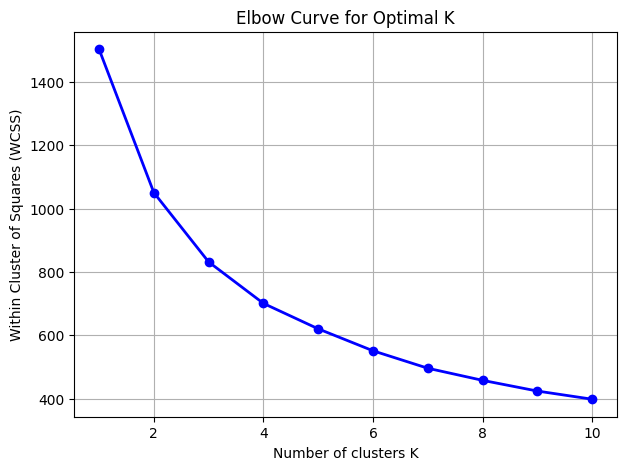

In [14]:
wcss = []
k_values = range(1, 11)

for k in k_values:
    # Use scaled data for clustering
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=15, max_iter=300)
    kmeans.fit(Clus_dataSet)
    wcss.append(kmeans.inertia_)  # inertia_ is WCSS for scaled data

# Plot elbow (WCSS)
plt.figure(figsize=(7,5))
plt.plot(k_values, wcss, 'bo-', linewidth=2)
plt.xlabel('Number of clusters K')
plt.ylabel('Within Cluster of Squares (WCSS)')
plt.title('Elbow Curve for Optimal K')
plt.grid(True)



---


# **Part B**

### Clustering according to optimal K


In [15]:
clusterNum = 3
k_means = KMeans(init="k-means++", n_clusters=clusterNum, n_init=12, random_state=42)
k_means.fit(Clus_dataSet)
labels = k_means.labels_.astype(int)

# Attach labels to original dataframe
df_with_labels = df.copy()
df_with_labels['Cluster'] = labels

print("Cluster counts:\n", df_with_labels['Cluster'].value_counts())

Cluster counts:
 Cluster
2    84
1    47
0    36
Name: count, dtype: int64




---

# **Part C**

### Groupby to compare clusters

In [16]:
# Print cluster sizes
cluster_sizes = df_with_labels.groupby('Cluster').size()
print("\nCluster sizes:\n", cluster_sizes)

# Print mean features in each cluster
cluster_mean = df_with_labels.groupby('Cluster').mean()
print("\nCluster mean of features:\n", cluster_mean)


Cluster sizes:
 Cluster
0    36
1    47
2    84
dtype: int64

Cluster mean of features:
          child_mort    exports    health    imports        income  inflation  \
Cluster                                                                        
0          5.000000  58.738889  8.807778  51.491667  45672.222222   2.671250   
1         92.961702  29.151277  6.388511  42.323404   3942.404255  12.019681   
2         21.927381  40.243917  6.200952  47.473404  12305.595238   7.600905   

         life_expec  total_fer          gdpp  
Cluster                                       
0         80.127778   1.752778  42494.444444  
1         59.187234   5.008085   1922.382979  
2         72.814286   2.307500   6486.452381  




---


# **Part (d)**
### 2D and 3D plots with chosen features

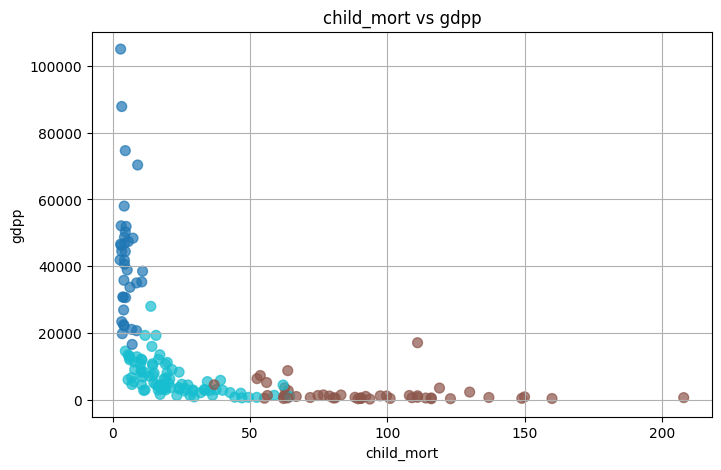

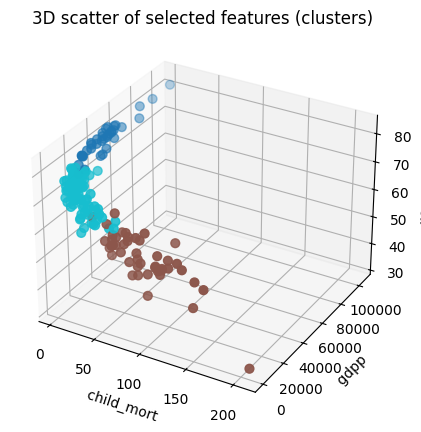

In [17]:
X_numeric = X.astype(float)

# 2D scatter: child_mort vs gdpp
plt.figure(figsize=(8,5))
plt.scatter(X_numeric[:, 0], X_numeric[:, 8], s=50, c=labels, cmap='tab10', alpha=0.7)
plt.xlabel('child_mort')
plt.ylabel('gdpp')
plt.title('child_mort vs gdpp')
plt.grid(True)
plt.show()

# 3D scatter: child_mort, gdpp, life_expec
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=(8,5))
ax = fig.add_subplot(111, projection='3d')
sc = ax.scatter(X_numeric[:, 0], X_numeric[:, 8], X_numeric[:, 6], c=labels, cmap='tab10', s=40)
ax.set_xlabel(' child_mort ')
ax.set_ylabel(' gdpp ')
ax.set_zlabel(' life_expec ')
plt.title('3D scatter of selected features (clusters)')
plt.show()